# Model Training & Explainability  
OneHealth-ML — Train Logistic Regression, Random Forest, XGBoost, and Knowledge Graph models for 7 diseases.  
Evaluate performance and produce SHAP explanations.

In [1]:
import sys, os
sys.path.append("..")

from src.models.train import main as train_main
from src.models.explain import explain_model, DISEASE_MAP

# Optional: display plots inline
%matplotlib inline

c:\Mir\OneHealth-ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json
import numpy as np
import os

PROCESSED_DIR = "../data/processed"

with open(os.path.join(PROCESSED_DIR, "feature_names.json")) as f:
    feature_names = json.load(f)

with open(os.path.join(PROCESSED_DIR, "leakage_map.json")) as f:
    leakage_map = json.load(f)

for label, feats in feature_names.items():
    excluded = set(leakage_map.get(label, []))
    leaked = [f for f in feats if f in excluded]
    if leaked:
        print(f"❌ {label}: LEAKAGE FOUND in feature_names.json: {leaked}")
    else:
        print(f"✅ {label}: No explicit leakage in feature_names.json")

✅ label_diabetes: No explicit leakage in feature_names.json
✅ label_hypertension: No explicit leakage in feature_names.json
✅ label_ckd: No explicit leakage in feature_names.json
✅ label_dyslipidemia: No explicit leakage in feature_names.json
✅ label_cvd: No explicit leakage in feature_names.json
✅ label_metabolic_syndrome: No explicit leakage in feature_names.json
✅ label_liver_disease: No explicit leakage in feature_names.json


In [3]:
from scipy.stats import pointbiserialr
import pandas as pd

diseases = ["diabetes","hypertension","ckd","dyslipidemia","cvd","metabolic_syndrome","liver_disease"]

for disease in diseases:
    X_train = np.load(f"../data/processed/{disease}_X_train.npy")
    y_train = np.load(f"../data/processed/{disease}_y_train.npy")
    with open("../data/processed/feature_names.json") as f:
        feats = json.load(f)[f"label_{disease}"]
    
    # Trim feature names to match array columns
    n_cols = X_train.shape[1]
    feats = feats[:n_cols]
    
    print(f"\n=== {disease} (n={X_train.shape[0]}) ===")
    for i, col in enumerate(feats):
        corr, pval = pointbiserialr(y_train, X_train[:, i])
        if abs(corr) > 0.85:
            print(f"  🚨 {col}: correlation={corr:.3f} (p={pval:.2e})")


=== diabetes (n=4065) ===

=== hypertension (n=4111) ===

=== ckd (n=4111) ===

=== dyslipidemia (n=3869) ===

=== cvd (n=4111) ===

=== metabolic_syndrome (n=3452) ===

=== liver_disease (n=4100) ===


In [4]:
train_main()


Training: diabetes


Generating walks (CPU: 1): 100%|██████████| 80/80 [00:01<00:00, 63.46it/s]


  knowledge_graph (test): AUROC=0.776, AUPRC=0.466, F1=0.511
  logistic_regression:
    Test:  AUROC=0.917, AUPRC=0.814, F1=0.685
    CV:    AUROC=0.900±0.017, AUPRC=0.781±0.025
  random_forest:
    Test:  AUROC=0.834, AUPRC=0.598, F1=0.561
    CV:    AUROC=0.837±0.014, AUPRC=0.613±0.033
  xgboost:
    Test:  AUROC=0.894, AUPRC=0.748, F1=0.612
    CV:    AUROC=0.883±0.010, AUPRC=0.714±0.023
  lightgbm:
    Test:  AUROC=0.892, AUPRC=0.738, F1=0.671
    CV:    AUROC=0.879±0.011, AUPRC=0.706±0.026
  catboost:
    Test:  AUROC=0.890, AUPRC=0.732, F1=0.644
    CV:    AUROC=0.877±0.008, AUPRC=0.705±0.025

Training: hypertension


Generating walks (CPU: 1): 100%|██████████| 80/80 [00:01<00:00, 65.12it/s]


  knowledge_graph (test): AUROC=0.776, AUPRC=0.816, F1=0.715
  logistic_regression:
    Test:  AUROC=0.840, AUPRC=0.875, F1=0.771
    CV:    AUROC=0.852±0.018, AUPRC=0.873±0.019
  random_forest:
    Test:  AUROC=0.819, AUPRC=0.845, F1=0.756
    CV:    AUROC=0.822±0.013, AUPRC=0.835±0.017
  xgboost:
    Test:  AUROC=0.863, AUPRC=0.896, F1=0.805
    CV:    AUROC=0.869±0.013, AUPRC=0.894±0.011
  lightgbm:
    Test:  AUROC=0.864, AUPRC=0.899, F1=0.791
    CV:    AUROC=0.870±0.013, AUPRC=0.898±0.011
  catboost:
    Test:  AUROC=0.858, AUPRC=0.891, F1=0.790
    CV:    AUROC=0.867±0.011, AUPRC=0.893±0.010

Training: ckd


...

  knowledge_graph (test): AUROC=0.758, AUPRC=0.333, F1=0.376
  logistic_regression:
    Test:  AUROC=0.845, AUPRC=0.447, F1=0.476
    CV:    AUROC=0.843±0.006, AUPRC=0.434±0.036
  random_forest:
    Test:  AUROC=0.827, AUPRC=0.422, F1=0.403
    CV:    AUROC=0.829±0.009, AUPRC=0.419±0.037
  xgboost:
    Test:  AUROC=0.855, AUPRC=0.477, F1=0.265
    CV:    AUROC=0.849±0.007, AUPRC=0.455±0.041
  lightgbm:
    Test:  AUROC=0.848, AUPRC=0.475, F1=0.437
    CV:    AUROC=0.846±0.008, AUPRC=0.459±0.038
  catboost:
    Test:  AUROC=0.852, AUPRC=0.466, F1=0.441
    CV:    AUROC=0.847±0.005, AUPRC=0.459±0.038

Training: metabolic_syndrome


Generating walks (CPU: 1): 100%|██████████| 80/80 [00:01<00:00, 69.32it/s]


  knowledge_graph (test): AUROC=0.779, AUPRC=0.645, F1=0.630
  logistic_regression:
    Test:  AUROC=0.828, AUPRC=0.700, F1=0.687
    CV:    AUROC=0.825±0.010, AUPRC=0.719±0.023
  random_forest:
    Test:  AUROC=0.833, AUPRC=0.736, F1=0.686
    CV:    AUROC=0.830±0.020, AUPRC=0.730±0.030
  xgboost:
    Test:  AUROC=0.853, AUPRC=0.765, F1=0.679
    CV:    AUROC=0.849±0.014, AUPRC=0.750±0.019
  lightgbm:
    Test:  AUROC=0.854, AUPRC=0.760, F1=0.712
    CV:    AUROC=0.848±0.016, AUPRC=0.750±0.021
  catboost:
    Test:  AUROC=0.852, AUPRC=0.767, F1=0.703
    CV:    AUROC=0.848±0.016, AUPRC=0.750±0.024

Training: liver_disease


Generating walks (CPU: 1): 100%|██████████| 80/80 [00:01<00:00, 59.64it/s]


  knowledge_graph (test): AUROC=0.758, AUPRC=0.311, F1=0.407
  logistic_regression:
    Test:  AUROC=0.783, AUPRC=0.425, F1=0.425
    CV:    AUROC=0.799±0.019, AUPRC=0.421±0.039
  random_forest:
    Test:  AUROC=0.792, AUPRC=0.444, F1=0.387
    CV:    AUROC=0.794±0.018, AUPRC=0.390±0.049
  xgboost:
    Test:  AUROC=0.823, AUPRC=0.471, F1=0.237
    CV:    AUROC=0.834±0.017, AUPRC=0.452±0.040
  lightgbm:
    Test:  AUROC=0.813, AUPRC=0.456, F1=0.460
    CV:    AUROC=0.829±0.016, AUPRC=0.441±0.043
  catboost:
    Test:  AUROC=0.815, AUPRC=0.469, F1=0.443
    CV:    AUROC=0.829±0.018, AUPRC=0.452±0.039

All models and metrics saved to ../models


## Model Performance Summary

In [5]:
import pandas as pd

metrics = pd.read_csv("../models/model_metrics.csv")
# Pivot to compare AUROC, AUPRC, F1 across models and diseases
pivot = metrics.pivot(index="disease", columns="model", values=["auroc", "auprc", "f1"])
pivot

auroc                                                \
model               catboost knowledge_graph  lightgbm logistic_regression   
disease                                                                      
ckd                 0.863880        0.822181  0.855283            0.833610   
cvd                 0.852019        0.758265  0.848218            0.845465   
diabetes            0.889561        0.776016  0.892310            0.917398   
dyslipidemia        0.849703        0.707115  0.857751            0.792205   
hypertension        0.858496        0.776479  0.864412            0.840425   
liver_disease       0.814570        0.758118  0.813216            0.782705   
metabolic_syndrome  0.852276        0.779446  0.853623            0.828122   

                                               auprc                  \
model              random_forest   xgboost  catboost knowledge_graph   
disease                                                                
ckd                     0.858216  0.864004  0.638975        0.504625   
cvd                     0.827226  0.855410  0.465672        0.333154   
diabetes                0.833993  0.893989  0.731586        0.465598   
dyslipidemia            0.756720  0.858698  0.907664        0.757328   
hypertension            0.819372  0.862812  0.890805        0.815984   
liver_disease           0.791936  0.822844  0.469105        0.311150   
metabolic_syndrome      0.833299  0.852941  0.766581        0.645007   

                                                                          \
model               lightgbm logistic_regression random_forest   xgboost   
disease                                                                    
ckd                 0.632352            0.579773      0.570838  0.649417   
cvd                 0.475235            0.446856      0.421893  0.476532   
diabetes            0.738492            0.814063      0.598103  0.748467   
dyslipidemia        0.910785            0.865035      0.828735  0.911493   
hypertension        0.899041            0.875388      0.845307  0.895737   
liver_disease       0.455782            0.424830      0.443909  0.470737   
metabolic_syndrome  0.759631            0.699655      0.735743  0.764727   

                          f1                                                \
model               catboost knowledge_graph  lightgbm logistic_regression   
disease                                                                      
ckd                 0.462046        0.371585  0.461538            0.440789   
cvd                 0.440980        0.376147  0.436937            0.475728   
diabetes            0.644182        0.511182  0.671353            0.685185   
dyslipidemia        0.759259        0.670465  0.737945            0.728477   
hypertension        0.790235        0.715196  0.791289            0.770909   
liver_disease       0.443038        0.407484  0.459821            0.424893   
metabolic_syndrome  0.703013        0.629630  0.712251            0.687316   

                                            
model              random_forest   xgboost  
disease                                     
ckd                     0.420382  0.551724  
cvd                     0.402597  0.265060  
diabetes                0.560976  0.612466  
dyslipidemia            0.699140  0.802218  
hypertension            0.755556  0.805172  
liver_disease           0.387454  0.237288  
metabolic_syndrome      0.685950  0.678748

In [6]:
# Full table including Brier, MCC, CV mean ± std
metrics = pd.read_csv("../models/model_metrics.csv")
metrics.head(10)

,auroc,auprc,f1,mcc,brier,disease,model,cv_auroc_mean,cv_auroc_std,cv_auprc_mean,cv_auprc_std,cv_f1_mean,cv_f1_std,cv_mcc_mean,cv_mcc_std,cv_brier_mean,cv_brier_std
0,0.776016,0.465598,0.511182,0.343092,0.198461,diabetes,knowledge_graph,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.917398,0.814063,0.685185,0.589047,0.115120,diabetes,logistic_regression,0.899911,0.017005,0.780931,0.024517,0.678597,0.033856,0.579575,0.046439,0.118636,0.007227
2,0.833993,0.598103,0.560976,0.421955,0.190881,diabetes,random_forest,0.836637,0.013762,0.613150,0.033380,0.565895,0.017928,0.427809,0.026877,0.190157,0.003462
3,0.893989,0.748467,0.612466,0.553940,0.103484,diabetes,xgboost,0.882715,0.009537,0.714489,0.022852,0.593769,0.022760,0.532773,0.026958,0.107818,0.003505
4,0.892310,0.738492,0.671353,0.573133,0.137405,diabetes,lightgbm,0.878680,0.010512,0.705730,0.025997,0.632162,0.019927,0.517349,0.026984,0.140057,0.008849
5,0.889561,0.731586,0.644182,0.537787,0.141711,diabetes,catboost,0.876835,0.008198,0.704552,0.024504,0.629804,0.018198,0.514358,0.025141,0.144222,0.007355
6,0.776479,0.815984,0.715196,0.392754,0.193883,hypertension,knowledge_graph,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.840425,0.875388,0.770909,0.512164,0.165732,hypertension,logistic_regression,0.852191,0.017783,0.872671,0.018696,0.792685,0.012967,0.535716,0.029568,0.156373,0.010044
8,0.819372,0.845307,0.755556,0.461703,0.190542,hypertension,random_forest,0.821923,0.013287,0.834953,0.016693,0.778354,0.011593,0.494474,0.029099,0.189165,0.002901
9,0.862812,0.895737,0.805172,0.552946,0.150852,hypertension,xgboost,0.869099,0.012794,0.894492,0.011424,0.815294,0.013105,0.563030,0.029066,0.146888,0.006896


In [7]:
metrics = pd.read_csv("../models/model_metrics.csv")
# Filter out KG (no CV) and pick best by cv_auprc_mean
ml_models = metrics[metrics["model"] != "knowledge_graph"].copy()
best_models = (
    ml_models.groupby("disease", as_index=False)
    .apply(lambda x: x.loc[x["cv_auprc_mean"].idxmax()])
)
best_models[["disease", "model", "cv_auprc_mean", "cv_auroc_mean", 
              "auprc", "auroc", "brier", "mcc"]]

,disease,model,cv_auprc_mean,cv_auroc_mean,auprc,auroc,brier,mcc
0,ckd,lightgbm,0.609884,0.887581,0.632352,0.855283,0.108500,0.422342
1,cvd,catboost,0.459426,0.847464,0.465672,0.852019,0.152893,0.377456
2,diabetes,logistic_regression,0.780931,0.899911,0.814063,0.917398,0.115120,0.589047
3,dyslipidemia,xgboost,0.898313,0.836803,0.911493,0.858698,0.156683,0.556970
4,hypertension,lightgbm,0.898322,0.870492,0.899041,0.864412,0.152691,0.554854
5,liver_disease,xgboost,0.451886,0.834096,0.470737,0.822844,0.097742,0.270364
6,metabolic_syndrome,lightgbm,0.750008,0.847917,0.759631,0.853623,0.155081,0.521789


In [8]:
import json

with open("../data/processed/feature_names.json") as f:
    fn = json.load(f)

for label in ["label_diabetes", "label_dyslipidemia"]:
    features = fn[label]
    print(f"\n{label}:")
    for suspect in ["LBXSGL", "LBXSCH", "LBXSTR"]:
        if suspect in features:
            print(f"  ⚠ {suspect} is present (likely leakage)")


label_diabetes:

label_dyslipidemia:


In [9]:
import json

with open("../data/processed/feature_names.json") as f:
    feature_names = json.load(f)
with open("../data/processed/leakage_map.json") as f:
    leakage_map = json.load(f)

disease_map = {
    "diabetes": "label_diabetes",
    "hypertension": "label_hypertension",
    "ckd": "label_ckd",
    "dyslipidemia": "label_dyslipidemia",
    "cvd": "label_cvd",
    "metabolic_syndrome": "label_metabolic_syndrome",
    "liver_disease": "label_liver_disease",
}

for disease, label in disease_map.items():
    features = feature_names[label]
    exclude_set = set(leakage_map.get(label, []))
    leaked = [f for f in features if f in exclude_set]
    if leaked:
        print(f"❌ {disease}: LEAKAGE FOUND – {len(leaked)} variables present that should be excluded:")
        for f in leaked:
            print(f"    {f}")
    else:
        print(f"✅ {disease}: No leakage (all excluded variables correctly removed)")
    print()

✅ diabetes: No leakage (all excluded variables correctly removed)

✅ hypertension: No leakage (all excluded variables correctly removed)

✅ ckd: No leakage (all excluded variables correctly removed)

✅ dyslipidemia: No leakage (all excluded variables correctly removed)

✅ cvd: No leakage (all excluded variables correctly removed)

✅ metabolic_syndrome: No leakage (all excluded variables correctly removed)

✅ liver_disease: No leakage (all excluded variables correctly removed)



In [10]:
import numpy as np

disease_list = ["diabetes","hypertension","ckd","dyslipidemia","cvd","metabolic_syndrome","liver_disease"]
for d in disease_list:
    y_train = np.load(f"../data/processed/{d}_y_train.npy")
    y_test = np.load(f"../data/processed/{d}_y_test.npy")
    print(f"{d:20s} train: {len(y_train)}, pos={y_train.sum():4d}  test: {len(y_test)}, pos={y_test.sum():4d}")

diabetes             train: 4065, pos= 906  test: 1017, pos= 227
hypertension         train: 4111, pos=2314  test: 1028, pos= 579
ckd                  train: 4111, pos= 378  test: 1028, pos=  95
dyslipidemia         train: 3869, pos=2275  test: 968, pos= 569
cvd                  train: 4111, pos= 506  test: 1028, pos= 127
metabolic_syndrome   train: 3452, pos=1290  test: 863, pos= 323
liver_disease        train: 4100, pos= 584  test: 1026, pos= 146


## SHAP Explainability (XGBoost)

In [11]:
# Generate SHAP summary plots for each disease (uses 200 test samples for speed)
for disease in DISEASE_MAP.keys():
    explain_model(disease, model_type="xgboost")

print("SHAP plots saved in ../reports/figures/")

SHAP plots saved for diabetes (xgboost).
SHAP plots saved for hypertension (xgboost).
SHAP plots saved for ckd (xgboost).
SHAP plots saved for dyslipidemia (xgboost).
SHAP plots saved for cvd (xgboost).
SHAP plots saved for metabolic_syndrome (xgboost).
SHAP plots saved for liver_disease (xgboost).
SHAP plots saved in ../reports/figures/


## Example: Waterfall plot for a single prediction (Liver Disease)

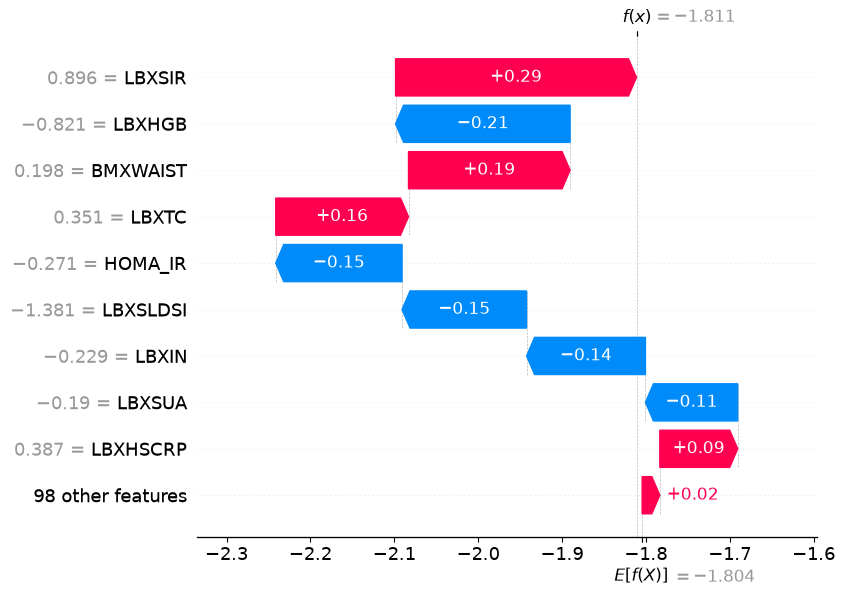

In [12]:
import joblib
import shap
import numpy as np
import json

disease = "liver_disease"
model = joblib.load(f"../models/{disease}_xgboost.pkl")
X_test = np.load(f"../data/processed/{disease}_X_test.npy")
with open("../data/processed/feature_names.json") as f:
    feat_names = json.load(f)["label_liver_disease"]

# Explain first test sample
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:1])
shap.waterfall_plot(shap.Explanation(values=shap_values[0],
                                     base_values=explainer.expected_value,
                                     data=X_test[0],
                                     feature_names=feat_names))

In [13]:
import json
with open("../data/processed/feature_names.json") as f:
    fn = json.load(f)

# Check for suspicious variables
for disease, label in [("cvd","label_cvd"), ("dyslipidemia","label_dyslipidemia")]:
    features = fn[label]
    # look for any self-reported diagnosis variables
    suspect = [f for f in features if f.startswith("MCQ") or f in ["LBXTC","LBDHDD","LBXTR"]]
    print(f"{disease}: {len(features)} features, suspect: {suspect}")

cvd: 105 features, suspect: ['MCQ160L', 'LBDHDD', 'LBXTC', 'LBXTR']
dyslipidemia: 108 features, suspect: ['MCQ160B', 'MCQ160C', 'MCQ160D', 'MCQ160E', 'MCQ160F', 'MCQ160L', 'MCQ300C', 'MCQ300A']
